<a href="https://colab.research.google.com/github/Kuiper-sun/TilapiaAI/blob/rt-detrv2/Copy_of_train_rt_detr_on_custom_dataset_with_transformers_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Select the runtime

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `L4 GPU`, and then click `Save`.

In [ ]:
!nvidia-smi

Thu Jun 26 13:58:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [ ]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


### Install dependencies

In [ ]:
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q git+https://github.com/roboflow/supervision.git
!pip install -q accelerate
!pip install -q roboflow
!pip install -q torchmetrics
!pip install -q "albumentations>=1.4.5"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━

### Imports

In [ ]:
import torch
import requests

import numpy as np
import supervision as sv
import albumentations as A

from PIL import Image
from pprint import pprint
from roboflow import Roboflow
from dataclasses import dataclass, replace
from google.colab import userdata
from torch.utils.data import Dataset
from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    TrainingArguments,
    Trainer
)
from torchmetrics.detection.mean_ap import MeanAveragePrecision

## Inference with pre-trained RT-DETR model

Load New Model

In [ ]:
# @title Load model

from transformers import AutoModelForObjectDetection, AutoProcessor
CHECKPOINT = "PekingU/rtdetr_r50vd_coco_o365"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForObjectDetection.from_pretrained("/content/drive/MyDrive/rt-detr-checkpoint")
processor = AutoProcessor.from_pretrained("/content/drive/MyDrive/rt-detr-checkpoint")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## Fine-tune RT-DETR on custom dataset

In [ ]:
# @title Download dataset from Roboflow Universe

rf = Roboflow(api_key="DgfLxMcP05vfRZ9iRjtJ")
project = rf.workspace("thesis-vbq8h").project("tilapia-gills-dataset")
version = project.version(4)
dataset = version.download("coco")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Tilapia-Gills-Dataset-4 in coco:: 100%|██████████| 1011/1011 [00:00<00:00, 4973.35it/s]


In [ ]:
import json

# 1. Load your COCO file
with open(f"{dataset.location}/train/_annotations.coco.json", "r") as f:
    coco = json.load(f)

# 2. Filter out the unwanted category (id == 0)
coco["categories"] = [cat for cat in coco["categories"] if cat["id"] != 0]

# 3. Remove any annotations labeled with category_id == 0
coco["annotations"] = [ann for ann in coco["annotations"] if ann["category_id"] != 0]

# 4. Rebuild your id2label and label2id
id2label = {cat["id"]: cat["name"] for cat in coco["categories"]}
label2id = {name: idx for idx, name in id2label.items()}

print(f"✅ Number of classes: {len(coco['categories'])}")
print(f"🧾 id2label: {id2label}")

✅ Number of classes: 3
🧾 id2label: {1: 'fresh_gills', 2: 'not_fresh_gills', 3: 'old_gills'}


In [ ]:
# Load training set
ds_train = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/train",
    annotations_path=f"{dataset.location}/train/_annotations.coco.json",
)

# Load test set
ds_test = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

print(f"✅ Number of training images: {len(ds_train)}")
print(f"✅ Number of test images: {len(ds_test)}")


✅ Number of training images: 906
✅ Number of test images: 99


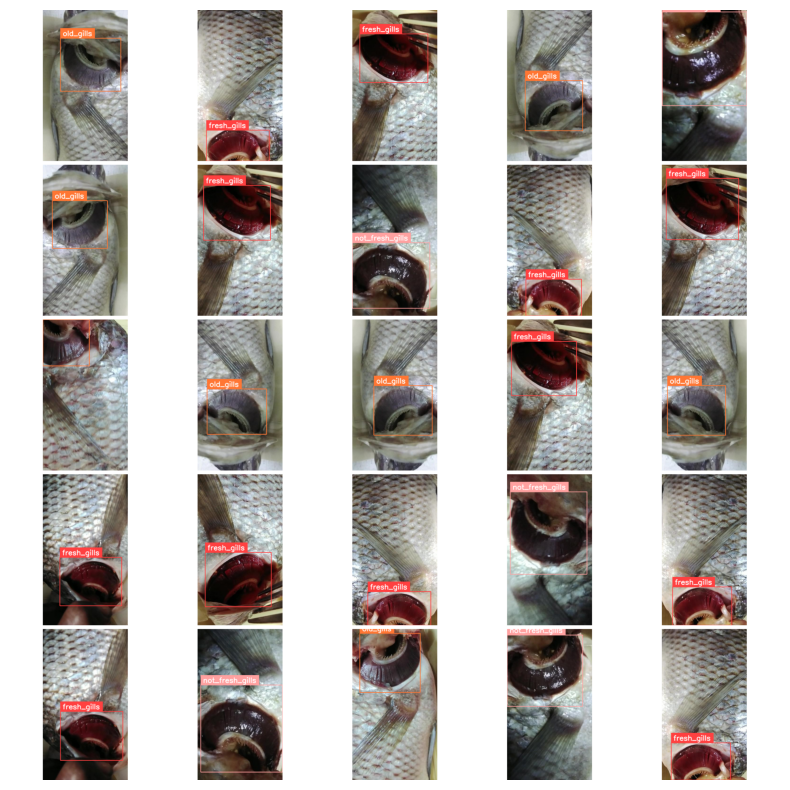

In [ ]:
# @title Display dataset sample

GRID_SIZE = 5

def annotate(image, annotations, classes):
    labels = [
        classes[class_id]
        for class_id
        in annotations.class_id
    ]

    bounding_box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator(text_scale=1, text_thickness=2)

    annotated_image = image.copy()
    annotated_image = bounding_box_annotator.annotate(annotated_image, annotations)
    annotated_image = label_annotator.annotate(annotated_image, annotations, labels=labels)
    return annotated_image

annotated_images = []
for i in range(GRID_SIZE * GRID_SIZE):
    _, image, annotations = ds_train[i]
    annotated_image = annotate(image, annotations, ds_train.classes)
    annotated_images.append(annotated_image)

grid = sv.create_tiles(
    annotated_images,
    grid_size=(GRID_SIZE, GRID_SIZE),
    single_tile_size=(400, 400),
    tile_padding_color=sv.Color.WHITE,
    tile_margin_color=sv.Color.WHITE
)
sv.plot_image(grid, size=(10, 10))

### Preprocess the data

To finetune a model, you must preprocess the data you plan to use to match precisely the approach used for the pre-trained model. [AutoImageProcessor](https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.AutoImageProcessor) takes care of processing image data to create `pixel_values`, `pixel_mask`, and `labels` that a DETR model can train with. The image processor has some attributes that you won't have to worry about:

- `image_mean = [0.485, 0.456, 0.406 ]`
- `image_std = [0.229, 0.224, 0.225]`

These are the mean and standard deviation used to normalize images during the model pre-training. These values are crucial to replicate when doing inference or finetuning a pre-trained image model.

Instantiate the image processor from the same checkpoint as the model you want to finetune.

In [ ]:
IMAGE_SIZE = 640

processor = AutoImageProcessor.from_pretrained(
    CHECKPOINT,
    do_resize=True,
    size={"width": IMAGE_SIZE, "height": IMAGE_SIZE},
)


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


preprocessor_config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

Before passing the images to the `processor`, apply two preprocessing transformations to the dataset:

- Augmenting images
- Reformatting annotations to meet RT-DETR expectations

First, to make sure the model does not overfit on the training data, you can apply image augmentation with any data augmentation library. Here we use [Albumentations](https://albumentations.ai/docs/). This library ensures that transformations affect the image and update the bounding boxes accordingly.

In [ ]:
train_augmentation_and_transform = A.Compose(
    [
        A.Perspective(p=0.1),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.1),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=25
    ),
)

valid_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=1
    ),
)

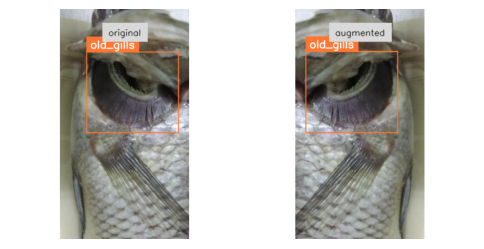

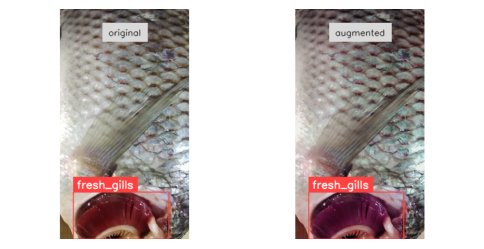

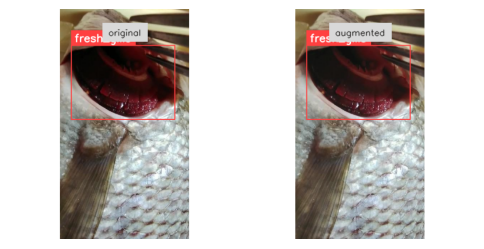

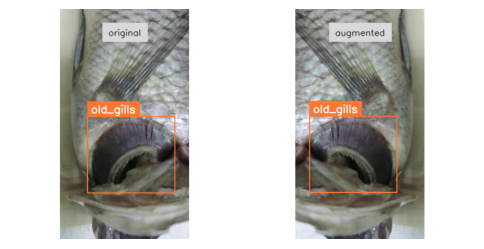

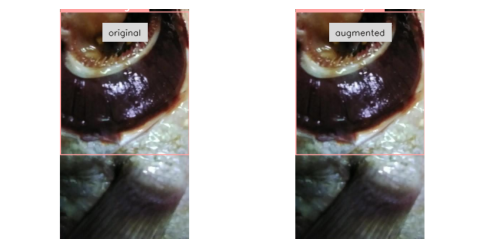

In [ ]:
# @title Visualize some augmented images

IMAGE_COUNT = 5

for i in range(IMAGE_COUNT):
    _, image, annotations = ds_train[i]

    output = train_augmentation_and_transform(
        image=image,
        bboxes=annotations.xyxy,
        category=annotations.class_id
    )

    augmented_image = output["image"]
    augmented_annotations = replace(
        annotations,
        xyxy=np.array(output["bboxes"]),
        class_id=np.array(output["category"])
    )

    annotated_images = [
        annotate(image, annotations, ds_train.classes),
        annotate(augmented_image, augmented_annotations, ds_train.classes)
    ]
    grid = sv.create_tiles(
        annotated_images,
        titles=['original', 'augmented'],
        titles_scale=0.5,
        single_tile_size=(400, 400),
        tile_padding_color=sv.Color.WHITE,
        tile_margin_color=sv.Color.WHITE
    )
    sv.plot_image(grid, size=(6, 6))

The `processor` expects the annotations to be in the following format: `{'image_id': int, 'annotations': List[Dict]}`, where each dictionary is a COCO object annotation. Let's add a function to reformat annotations for a single example:

In [ ]:
class PyTorchDetectionDataset(Dataset):
    def __init__(self, dataset: sv.DetectionDataset, processor, transform: A.Compose = None):
        self.dataset = dataset
        self.processor = processor
        self.transform = transform

    @staticmethod
    def annotations_as_coco(image_id, categories, boxes):
        annotations = []
        for category, bbox in zip(categories, boxes):
            x1, y1, x2, y2 = bbox
            formatted_annotation = {
                "image_id": image_id,
                "category_id": category,
                "bbox": [x1, y1, x2 - x1, y2 - y1],
                "iscrowd": 0,
                "area": (x2 - x1) * (y2 - y1),
            }
            annotations.append(formatted_annotation)

        return {
            "image_id": image_id,
            "annotations": annotations,
        }

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        _, image, annotations = self.dataset[idx]

        # Convert image to RGB numpy array
        image = image[:, :, ::-1]
        boxes = annotations.xyxy
        categories = annotations.class_id

        if self.transform:
            transformed = self.transform(
                image=image,
                bboxes=boxes,
                category=categories
            )
            image = transformed["image"]
            boxes = transformed["bboxes"]
            categories = transformed["category"]


        formatted_annotations = self.annotations_as_coco(
            image_id=idx, categories=categories, boxes=boxes)
        result = self.processor(
            images=image, annotations=formatted_annotations, return_tensors="pt")

        # Image processor expands batch dimension, lets squeeze it
        result = {k: v[0] for k, v in result.items()}

        return result

Now you can combine the image and annotation transformations to use on a batch of examples:

In [ ]:
pytorch_dataset_train = PyTorchDetectionDataset(
    ds_train, processor, transform=train_augmentation_and_transform)
pytorch_dataset_test = PyTorchDetectionDataset(
    ds_test, processor, transform=valid_transform)

pytorch_dataset_train[15]

{'pixel_values': tensor([[[0.2039, 0.2157, 0.2353,  ..., 0.3333, 0.3333, 0.3333],
          [0.2157, 0.2235, 0.2392,  ..., 0.2980, 0.3020, 0.3020],
          [0.2235, 0.2314, 0.2471,  ..., 0.2549, 0.2588, 0.2588],
          ...,
          [0.6353, 0.6157, 0.5804,  ..., 0.1333, 0.1333, 0.1333],
          [0.6196, 0.6157, 0.6039,  ..., 0.1333, 0.1333, 0.1333],
          [0.6118, 0.6235, 0.6471,  ..., 0.1333, 0.1333, 0.1333]],
 
         [[0.1843, 0.1922, 0.2039,  ..., 0.3294, 0.3294, 0.3294],
          [0.1922, 0.2000, 0.2118,  ..., 0.2941, 0.2980, 0.2980],
          [0.2000, 0.2078, 0.2196,  ..., 0.2510, 0.2549, 0.2549],
          ...,
          [0.5569, 0.5373, 0.5020,  ..., 0.1412, 0.1412, 0.1412],
          [0.5373, 0.5294, 0.5176,  ..., 0.1412, 0.1412, 0.1412],
          [0.5294, 0.5412, 0.5647,  ..., 0.1412, 0.1412, 0.1412]],
 
         [[0.1569, 0.1608, 0.1725,  ..., 0.3098, 0.3098, 0.3098],
          [0.1647, 0.1686, 0.1804,  ..., 0.2745, 0.2784, 0.2784],
          [0.1725, 0.176

You have successfully augmented the images and prepared their annotations. In the final step, create a custom collate_fn to batch images together.

In [ ]:
def collate_fn(batch):
    data = {}
    data["pixel_values"] = torch.stack([x["pixel_values"] for x in batch])
    data["labels"] = [x["labels"] for x in batch]
    return data

## Preparing function to compute mAP

In [ ]:
id2label = {id: label for id, label in enumerate(ds_train.classes)}
label2id = {label: id for id, label in enumerate(ds_train.classes)}


@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor


class MAPEvaluator:

    def __init__(self, image_processor, threshold=0.00, id2label=None):
        self.image_processor = image_processor
        self.threshold = threshold
        self.id2label = id2label

    def collect_image_sizes(self, targets):
        """Collect image sizes across the dataset as list of tensors with shape [batch_size, 2]."""
        image_sizes = []
        for batch in targets:
            batch_image_sizes = torch.tensor(np.array([x["size"] for x in batch]))
            image_sizes.append(batch_image_sizes)
        return image_sizes

    def collect_targets(self, targets, image_sizes):
        post_processed_targets = []
        for target_batch, image_size_batch in zip(targets, image_sizes):
            for target, (height, width) in zip(target_batch, image_size_batch):
                boxes = target["boxes"]
                boxes = sv.xcycwh_to_xyxy(boxes)
                boxes = boxes * np.array([width, height, width, height])
                boxes = torch.tensor(boxes)
                labels = torch.tensor(target["class_labels"])
                post_processed_targets.append({"boxes": boxes, "labels": labels})
        return post_processed_targets

    def collect_predictions(self, predictions, image_sizes):
        post_processed_predictions = []
        for batch, target_sizes in zip(predictions, image_sizes):
            batch_logits, batch_boxes = batch[1], batch[2]
            output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
            post_processed_output = self.image_processor.post_process_object_detection(
                output, threshold=self.threshold, target_sizes=target_sizes
            )
            post_processed_predictions.extend(post_processed_output)
        return post_processed_predictions

    @torch.no_grad()
    def __call__(self, evaluation_results):

        predictions, targets = evaluation_results.predictions, evaluation_results.label_ids

        image_sizes = self.collect_image_sizes(targets)
        post_processed_targets = self.collect_targets(targets, image_sizes)
        post_processed_predictions = self.collect_predictions(predictions, image_sizes)

        evaluator = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
        evaluator.warn_on_many_detections = False
        evaluator.update(post_processed_predictions, post_processed_targets)

        metrics = evaluator.compute()

        # Replace list of per class metrics with separate metric for each class
        classes = metrics.pop("classes")
        map_per_class = metrics.pop("map_per_class")
        mar_100_per_class = metrics.pop("mar_100_per_class")
        for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
            class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
            metrics[f"map_{class_name}"] = class_map
            metrics[f"mar_100_{class_name}"] = class_mar

        metrics = {k: round(v.item(), 4) for k, v in metrics.items()}

        return metrics

eval_compute_metrics_fn = MAPEvaluator(image_processor=processor, threshold=0.01, id2label=id2label)

## Training the detection model

You have done most of the heavy lifting in the previous sections, so now you are ready to train your model! The images in this dataset are still quite large, even after resizing. This means that finetuning this model will require at least one GPU.

Training involves the following steps:

- Load the model with [`AutoModelForObjectDetection`](https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.AutoModelForObjectDetection) using the same checkpoint as in the preprocessing.
- Define your training hyperparameters in [`TrainingArguments`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.TrainingArguments).
- Pass the training arguments to [`Trainer`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer) along with the model, dataset, image processor, and data collator.
- Call [`train()`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train) to finetune your model.

When loading the model from the same checkpoint that you used for the preprocessing, remember to pass the `label2id` and `id2label` maps that you created earlier from the dataset's metadata. Additionally, we specify `ignore_mismatched_sizes=True` to replace the existing classification head with a new one.

In [ ]:
model = AutoModelForObjectDetection.from_pretrained(
    CHECKPOINT,
    id2label=id2label,
    label2id=label2id,
    anchor_image_size=None,
    ignore_mismatched_sizes=True,
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

Some weights of RTDetrForObjectDetection were not initialized from the model checkpoint at PekingU/rtdetr_r50vd_coco_o365 and are newly initialized because the shapes did not match:
- model.decoder.class_embed.0.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([4]) in the model instantiated
- model.decoder.class_embed.0.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([4, 256]) in the model instantiated
- model.decoder.class_embed.1.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([4]) in the model instantiated
- model.decoder.class_embed.1.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([4, 256]) in the model instantiated
- model.decoder.class_embed.2.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([4]) in the model instantiated
- model.decoder.class_embed.2.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([4, 256]) in the model instantiated
- model.

In the [`TrainingArguments`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.TrainingArguments) use `output_dir` to specify where to save your model, then configure hyperparameters as you see fit. For `num_train_epochs=10` training will take about 15 minutes in Google Colab T4 GPU, increase the number of epoch to get better results.

Important notes:

- Do not remove unused columns because this will drop the image column. Without the image column, you can't create `pixel_values`. For this reason, set `remove_unused_columns` to `False`.
- Set `eval_do_concat_batches=False` to get proper evaluation results. Images have different number of target boxes, if batches are concatenated we will not be able to determine which boxes belongs to particular image.

In [ ]:
training_args = TrainingArguments(
    output_dir=f"{dataset.name.replace(' ', '-')}-finetune",
    num_train_epochs=50,
    max_grad_norm=0.1,
    learning_rate=5e-5,
    warmup_steps=300,
    per_device_train_batch_size=16,
    dataloader_num_workers=2,
    metric_for_best_model="eval_map",
    greater_is_better=True,
    load_best_model_at_end=False,
    eval_strategy="no",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    eval_do_concat_batches=False,
)

Finally, bring everything together, and call [`train()`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train):

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=pytorch_dataset_train,
    tokenizer=processor,
    data_collator=collate_fn,
    compute_metrics=eval_compute_metrics_fn,
)

trainer.train()

`tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: supnetkieferson (supnetkieferson-dmnhs) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss


KeyboardInterrupt: 

In [ ]:
from transformers import AutoModelForObjectDetection, AutoProcessor

model = AutoModelForObjectDetection.from_pretrained("/content/drive/MyDrive/rt-detr-checkpoint")
processor = AutoProcessor.from_pretrained("/content/drive/MyDrive/rt-detr-checkpoint")


## Evaluate

In [ ]:
# @title Collect predictions

targets = []
predictions = []

for i in range(len(ds_test)):
    path, sourece_image, annotations = ds_test[i]

    image = Image.open(path)
    inputs = processor(image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    w, h = image.size
    results = processor.post_process_object_detection(
        outputs, target_sizes=[(h, w)], threshold=0.3)

    detections = sv.Detections.from_transformers(results[0])

    targets.append(annotations)
    predictions.append(detections)

In [ ]:
# @title Calculate mAP
mean_average_precision = sv.MeanAveragePrecision.from_detections(
    predictions=predictions,
    targets=targets,
)

print(f"map50_95: {mean_average_precision.map50_95:.2f}")
print(f"map50: {mean_average_precision.map50:.2f}")
print(f"map75: {mean_average_precision.map75:.2f}")

map50_95: 0.76
map50: 0.95
map75: 0.93


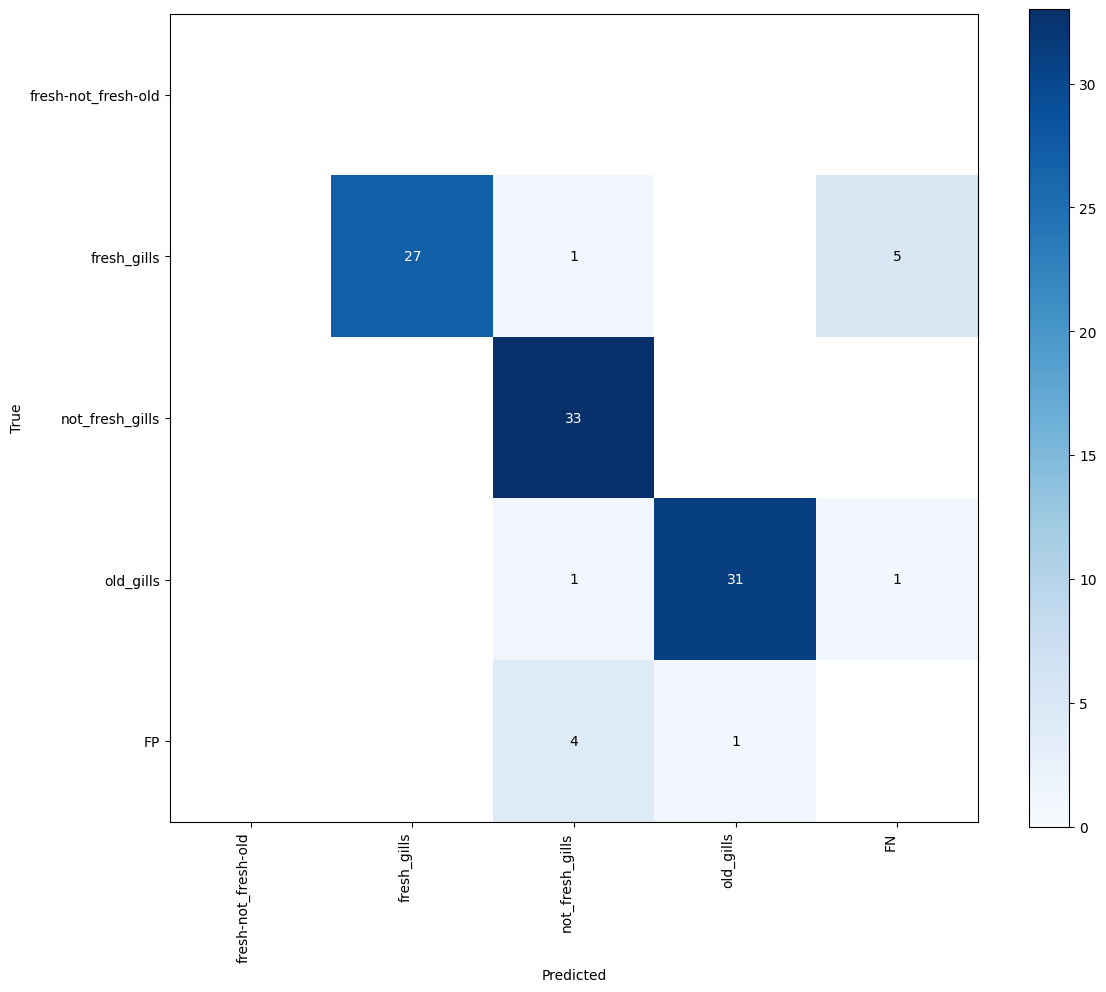

In [ ]:
# @title Calculate Confusion Matrix
confusion_matrix = sv.ConfusionMatrix.from_detections(
    predictions=predictions,
    targets=targets,
    classes=ds_test.classes
)

_ = confusion_matrix.plot()

## Save fine-tuned model on hard drive

In [ ]:
model.save_pretrained("/content/rt-detr/")
processor.save_pretrained("/content/rt-detr/")

# Create a directory in your Google Drive for saving the model
save_path = "/content/drive/MyDrive/rt-detr-checkpoint"
os.makedirs(save_path, exist_ok=True)

# Save model and processor
model.save_pretrained(save_path)
processor.save_pretrained(save_path)

['/content/drive/MyDrive/rt-detr-checkpoint/preprocessor_config.json']

In [ ]:
model = AutoModelForObjectDetection.from_pretrained("/content/drive/MyDrive/rt-detr-checkpoint")
processor = AutoProcessor.from_pretrained("/content/drive/MyDrive/rt-detr-checkpoint")

## Inference with fine-tuned RT-DETR model

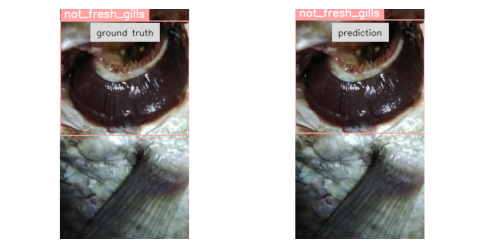

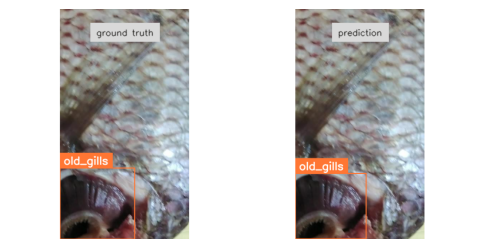

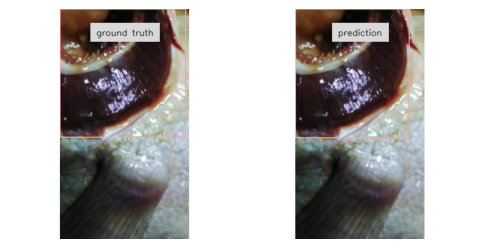

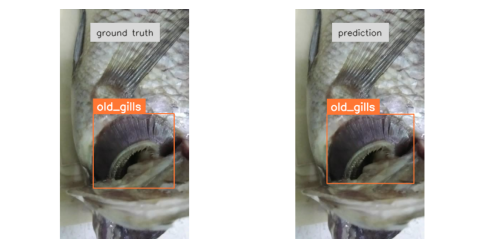

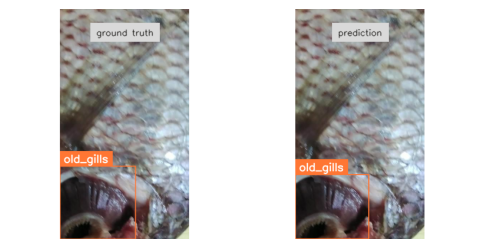

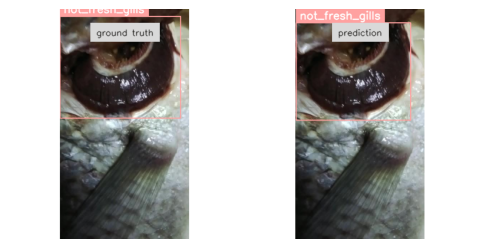

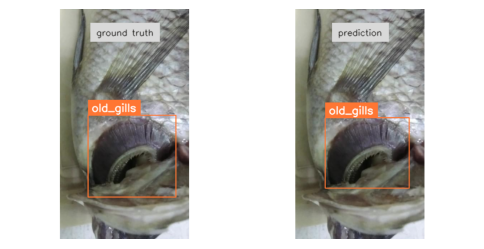

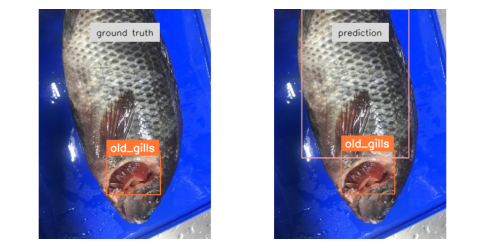

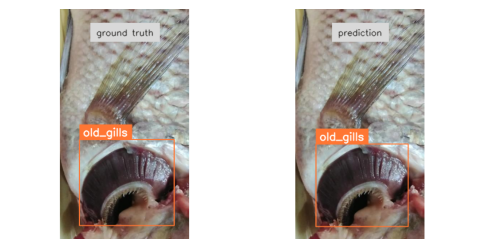

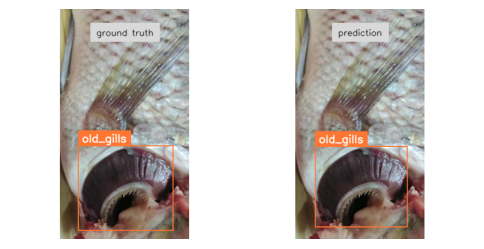

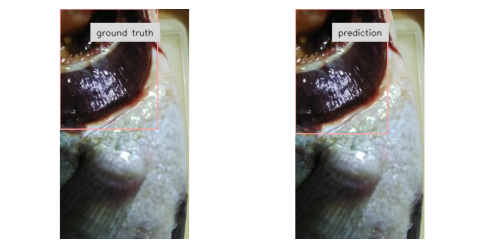

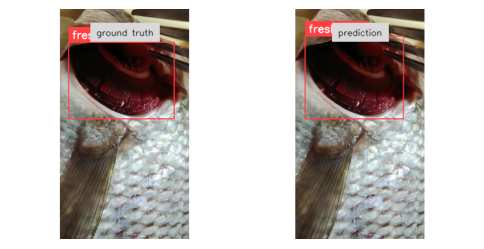

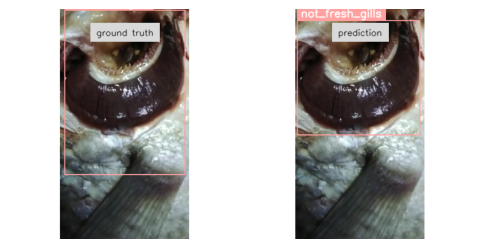

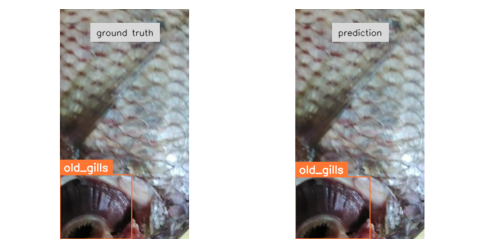

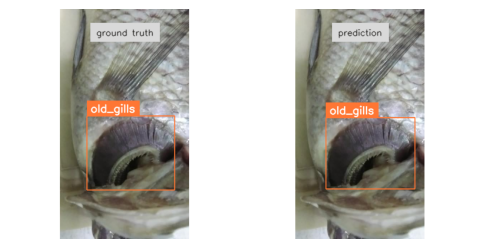

In [ ]:
IMAGE_COUNT = 15

for i in range(IMAGE_COUNT):
    path, sourece_image, annotations = ds_test[i]

    image = Image.open(path)
    inputs = processor(image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    w, h = image.size
    results = processor.post_process_object_detection(
        outputs, target_sizes=[(h, w)], threshold=0.3)

    detections = sv.Detections.from_transformers(results[0]).with_nms(threshold=0.1)

    annotated_images = [
        annotate(sourece_image, annotations, ds_train.classes),
        annotate(sourece_image, detections, ds_train.classes)
    ]
    grid = sv.create_tiles(
        annotated_images,
        titles=['ground truth', 'prediction'],
        titles_scale=0.5,
        single_tile_size=(400, 400),
        tile_padding_color=sv.Color.WHITE,
        tile_margin_color=sv.Color.WHITE
    )
    sv.plot_image(grid, size=(6, 6))

# Inference to Run a single image

In [ ]:
from PIL import Image
import torch
import supervision as sv  # Assuming you're using Supervision for visualization

# Set your image path in Google Drive
image_path = "/content/drive/MyDrive/datasets/Tilapia_Gills_Dataset/IMG_0847.JPG"  # 🔁 change this path to your actual image

# Load image
image = Image.open(image_path).convert("RGB")
w, h = image.size

# Preprocess image
inputs = processor(image, return_tensors="pt").to(DEVICE)

# Inference
with torch.no_grad():
    outputs = model(**inputs)

# Post-process results
results = processor.post_process_object_detection(
    outputs, target_sizes=[(h, w)], threshold=0.3)

# Convert to Supervision Detections and apply NMS
detections = sv.Detections.from_transformers(results[0]).with_nms(threshold=0.1)

# Annotate the image
annotated = annotate(image, detections, ds_train.classes)

# Show result
sv.plot_image(annotated, size=(6, 6))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/datasets/Tilapia_Gills_Dataset/IMG_0847.JPG'

# Calculate Metrics


In [ ]:
import numpy as np

# 1) grab the raw confusion‐matrix counts
cm = confusion_matrix.matrix   # shape [num_classes, num_classes]

# 2) overall accuracy = sum of diagonal / total
accuracy = np.trace(cm) / cm.sum()

# 3) per‐class precision & recall
#    precision_i = cm[i,i] / sum_j cm[j,i]
#    recall_i    = cm[i,i] / sum_j cm[i,j]
with np.errstate(divide='ignore', invalid='ignore'):
    precision_per_class = np.diag(cm) / cm.sum(axis=0)
    recall_per_class    = np.diag(cm) / cm.sum(axis=1)
    f1_per_class        = 2 * (precision_per_class * recall_per_class) \
                          / (precision_per_class + recall_per_class)

# 4) macro‐averaged metrics (just mean over classes)
precision_macro = np.nanmean(precision_per_class)
recall_macro    = np.nanmean(recall_per_class)
f1_macro        = np.nanmean(f1_per_class)

# 5) print everything nicely
print(f"Accuracy:           {accuracy:.4f}")
print(f"Macro Precision:    {precision_macro:.4f}")
print(f"Macro Recall:       {recall_macro:.4f}")
print(f"Macro F1:           {f1_macro:.4f}\n")

print("Per‐class metrics:")
for cls, p, r, f1 in zip(ds_test.classes,
                         precision_per_class,
                         recall_per_class,
                         f1_per_class):
    print(f"  {cls:15s} P={p:.3f}  R={r:.3f}  F1={f1:.3f}")

Accuracy:           0.8942
Macro Precision:    0.9049
Macro Recall:       0.8955
Macro F1:           0.8950

Per‐class metrics:
  fresh-not_fresh-old P=nan  R=nan  F1=nan
  fresh_gills     P=1.000  R=0.818  F1=0.900
  not_fresh_gills P=0.846  R=1.000  F1=0.917
  old_gills       P=0.868  R=0.868  F1=0.868


In [ ]:
import numpy as np

# 1) Grab the raw confusion matrix counts
cm_full = confusion_matrix.matrix  # shape [num_classes, num_classes]
classes_full = ds_test.classes

# 2) Exclude the undesired class
excluded_class = 'fresh-not_fresh-old'

# Check if excluded class exists
if excluded_class not in classes_full:
    raise ValueError(f"Class '{excluded_class}' not found in {classes_full}")

excluded_idx = classes_full.index(excluded_class)

# Remove the corresponding row and column from the confusion matrix
mask = np.arange(len(classes_full)) != excluded_idx
cm = cm_full[np.ix_(mask, mask)]
classes = [cls for i, cls in enumerate(classes_full) if i != excluded_idx]

# Validate that confusion matrix is square after filtering
assert cm.shape[0] == cm.shape[1], "Confusion matrix should be square after filtering"

# 3) Overall accuracy = sum of diagonal / total
accuracy = np.trace(cm) / cm.sum()

# 4) Per-class precision & recall
with np.errstate(divide='ignore', invalid='ignore'):
    precision_per_class = np.diag(cm) / cm.sum(axis=0)
    recall_per_class    = np.diag(cm) / cm.sum(axis=1)
    f1_per_class        = 2 * (precision_per_class * recall_per_class) \
                          / (precision_per_class + recall_per_class)

# Handle any NaN values that might arise from division by zero
precision_per_class = np.nan_to_num(precision_per_class, nan=0.0)
recall_per_class = np.nan_to_num(recall_per_class, nan=0.0)
f1_per_class = np.nan_to_num(f1_per_class, nan=0.0)

# 5) Macro-averaged metrics
precision_macro = np.nanmean(precision_per_class)
recall_macro    = np.nanmean(recall_per_class)
f1_macro        = np.nanmean(f1_per_class)

# 6) Print everything nicely
print("="*50)
print("CLASSIFICATION METRICS")
print("="*50)
print(f"Accuracy:           {accuracy:.4f}")
print(f"Macro Precision:    {precision_macro:.4f}")
print(f"Macro Recall:       {recall_macro:.4f}")
print(f"Macro F1:           {f1_macro:.4f}")
print()

print("Per-class metrics:")
print("-" * 40)
for cls, p, r, f1 in zip(classes, precision_per_class, recall_per_class, f1_per_class):
    print(f"  {cls:15s} P={p:.3f}  R={r:.3f}  F1={f1:.3f}")

print()
print("Confusion Matrix (after excluding '{}'):".format(excluded_class))
print("-" * 40)
print("Classes:", classes)
print("Matrix shape:", cm.shape)
print(cm)


CLASSIFICATION METRICS
Accuracy:           0.8942
Macro Precision:    0.9049
Macro Recall:       0.8955
Macro F1:           0.8950

Per-class metrics:
----------------------------------------
  fresh_gills     P=1.000  R=0.818  F1=0.900
  not_fresh_gills P=0.846  R=1.000  F1=0.917
  old_gills       P=0.868  R=0.868  F1=0.868

Confusion Matrix (after excluding 'fresh-not_fresh-old'):
----------------------------------------
Classes: ['fresh_gills', 'not_fresh_gills', 'old_gills']
Matrix shape: (3, 3)
[[27.  1.  5.]
 [ 0. 33.  0.]
 [ 0.  5. 33.]]
